# ASKAP/FAST and PKS/FAST ratio vs. parameter grid

Reads `DM_ratio_grid_results.csv` (produced by `DM_ratio_grid.py`), plots the ASKAP/FAST and PKS/FAST detected-FRB-count ratios across the `alpha_intrinsic` x `L_STAR` x `ALPHA_SCH` grid, shades the target ranges 0.05 < ASKAP/FAST < 0.2 and 0.85 < PKS/FAST < 1.2, and lists which parameter combinations fall inside both bands.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- load the grid-search results ----
CSV_PATH = "/home/thsu/FRB_population/DM_ratio/DM_ratio_grid_results.csv"
df = pd.read_csv(CSV_PATH)
df = df.sort_values(["ALPHA_SCH", "alpha_intrinsic", "L_STAR"]).reset_index(drop=True)
df.head()


,alpha_intrinsic,L_STAR,ALPHA_SCH,n_ASKAP,n_PKS,n_FAST,ASKAP_PKS_ratio,PKS_FAST_ratio,ASKAP_FAST_ratio,plot_file
0,-2.5,1.000000e+13,-1.8,0.195984,0.971920,2.846341,0.201646,0.341463,0.068855,DM_dist_alpha-2.5_Lstar1e+13_alphaSch-1.8.png
1,-2.5,3.000000e+13,-1.8,0.365284,1.405898,3.334389,0.259823,0.421636,0.109551,DM_dist_alpha-2.5_Lstar3e+13_alphaSch-1.8.png
2,-2.5,5.000000e+13,-1.8,0.497301,1.635324,3.539042,0.304099,0.462081,0.140519,DM_dist_alpha-2.5_Lstar5e+13_alphaSch-1.8.png
3,-2.5,8.000000e+13,-1.8,0.636573,1.856670,3.701896,0.342858,0.501546,0.171959,DM_dist_alpha-2.5_Lstar8e+13_alphaSch-1.8.png
4,-2.5,1.000000e+14,-1.8,0.713641,1.964681,3.777228,0.363235,0.520138,0.188932,DM_dist_alpha-2.5_Lstar1e+14_alphaSch-1.8.png


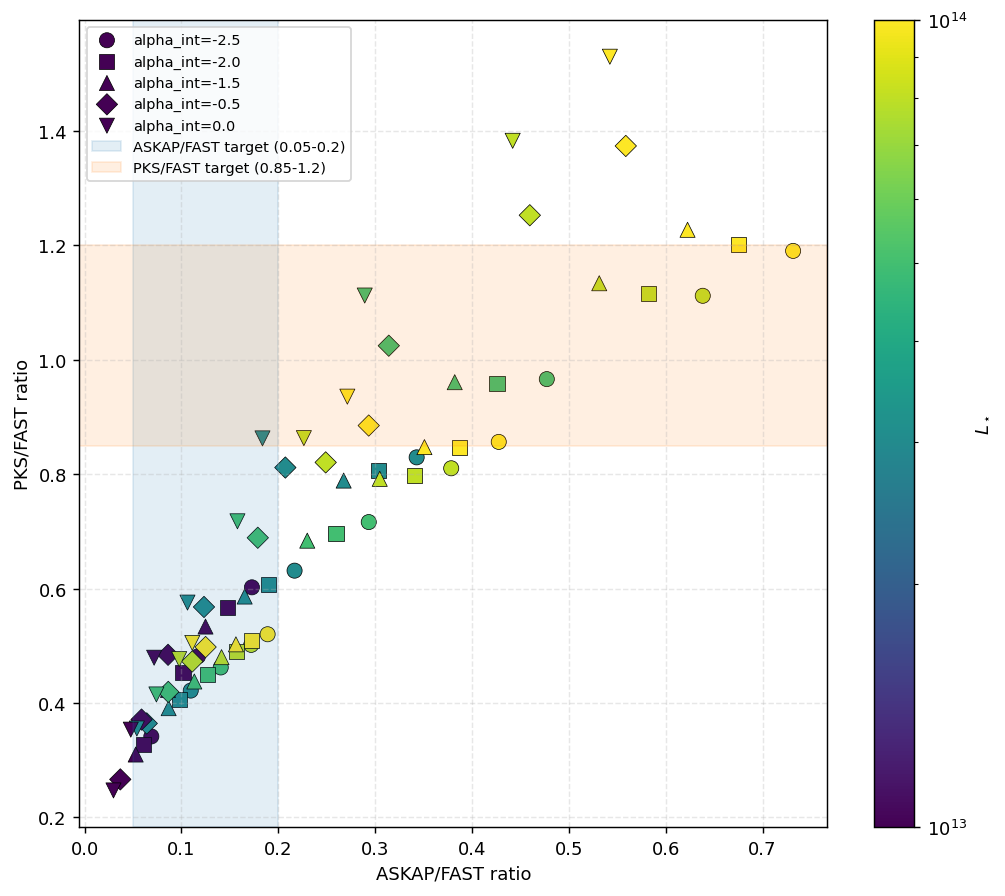

In [7]:
# ---- target ranges to shade ----
ASKAP_FAST_LOW, ASKAP_FAST_HIGH = 0.05, 0.2
PKS_FAST_LOW, PKS_FAST_HIGH = 0.85, 1.2

# ---- one marker shape per alpha_intrinsic value ----
alpha_intrinsic_vals = sorted(df["alpha_intrinsic"].unique())
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]  # extend if you sweep >8 alphas
marker_map = {a: markers[i % len(markers)] for i, a in enumerate(alpha_intrinsic_vals)}

fig, ax = plt.subplots(figsize=(8, 7), dpi=130)

norm = plt.matplotlib.colors.LogNorm(vmin=df["L_STAR"].min(), vmax=df["L_STAR"].max())
for a_int in alpha_intrinsic_vals:
    sub = df[df["alpha_intrinsic"] == a_int]
    sc = ax.scatter(sub["ASKAP_FAST_ratio"], sub["PKS_FAST_ratio"],
                     c=sub["L_STAR"], cmap="viridis", norm=norm,
                     marker=marker_map[a_int], s=70, edgecolor="k", linewidth=0.4,
                     label=f"alpha_int={a_int}")

# shaded target regions
ax.axvspan(ASKAP_FAST_LOW, ASKAP_FAST_HIGH, color="tab:blue", alpha=0.12,
           label=f"ASKAP/FAST target ({ASKAP_FAST_LOW}-{ASKAP_FAST_HIGH})")
ax.axhspan(PKS_FAST_LOW, PKS_FAST_HIGH, color="tab:orange", alpha=0.12,
           label=f"PKS/FAST target ({PKS_FAST_LOW}-{PKS_FAST_HIGH})")

ax.set_xlabel("ASKAP/FAST ratio")
ax.set_ylabel("PKS/FAST ratio")

ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=8, loc="upper left", ncol=1)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$L_\star$")

plt.tight_layout()
plt.savefig("/home/thsu/FRB_population/DM_ratio/ratio_scatter.png", bbox_inches="tight")
plt.show()

In [3]:
# ---- combinations landing inside BOTH target bands ----
mask_both = (
    df["ASKAP_FAST_ratio"].between(ASKAP_FAST_LOW, ASKAP_FAST_HIGH)
    & df["PKS_FAST_ratio"].between(PKS_FAST_LOW, PKS_FAST_HIGH)
)
matches = df.loc[mask_both, ["alpha_intrinsic", "L_STAR", "ALPHA_SCH",
                              "ASKAP_FAST_ratio", "PKS_FAST_ratio"]]

print(f"{len(matches)} combination(s) with ASKAP/FAST in "
      f"[{ASKAP_FAST_LOW}, {ASKAP_FAST_HIGH}] AND PKS/FAST in "
      f"[{PKS_FAST_LOW}, {PKS_FAST_HIGH}]:\n")
print(matches.to_string(index=False))

# ---- (for reference) combinations matching each band individually ----
mask_askap_only = df["ASKAP_FAST_ratio"].between(ASKAP_FAST_LOW, ASKAP_FAST_HIGH)
mask_pks_only = df["PKS_FAST_ratio"].between(PKS_FAST_LOW, PKS_FAST_HIGH)
print(f"\n(for reference: {mask_askap_only.sum()} combo(s) in the ASKAP/FAST band alone, "
      f"{mask_pks_only.sum()} combo(s) in the PKS/FAST band alone)")


1 combination(s) with ASKAP/FAST in [0.05, 0.2] AND PKS/FAST in [0.85, 1.2]:

 alpha_intrinsic       L_STAR  ALPHA_SCH  ASKAP_FAST_ratio  PKS_FAST_ratio
             0.0 3.000000e+13       -1.2          0.183623        0.862608

(for reference: 39 combo(s) in the ASKAP/FAST band alone, 14 combo(s) in the PKS/FAST band alone)
